# NB 23b - `test_internal` slice selector for the FE showcase (46ch detrended PCA)

Same idea as NB 23, but scored with the **FE-blessed 46-channel detrended PCA**
(`models/pca_fe_46ch.pkl`, threshold from `models/fe_46ch_<ts>.json`) on the
**Kaggle internal test slice** (rows 12.7M..14.7M of `train_full_scaled`, 25 events).

Slides a fixed-length window across the test slice, ranks every candidate by
anomaly density, and plots the top picks alongside the FE model's predictions.
A manual slice explorer at the bottom lets you cut any range by hand and save it
as a `test_api*` artefact for the FastAPI demo.

Whether the model *catches* every event isn't the criterion — the FE only needs a
busy-looking section.

## 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json, sys, time
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import median_filter

from sentinel.ml_logic.data    import find_anomaly_segments
from sentinel.ml_logic.scorer  import score_windows_detrended, clean_predictions
from sentinel.ml_logic.viz     import plot_timeline
from sentinel.params           import (PROCESSED_DIR, MODELS_DIR, WINDOW_SIZE,
                                       ANOMALY_COLOR, NOMINAL_COLOR)

import pickle

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

VAL_END   = 12_700_000     # start of the kaggle internal test slice
KAGGLE    = PROCESSED_DIR / 'kaggle'
print('PROCESSED_DIR :', PROCESSED_DIR)
print('MODELS_DIR    :', MODELS_DIR)
print('WINDOW_SIZE   :', WINDOW_SIZE)

PROCESSED_DIR : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed
MODELS_DIR    : /Users/helena.schulz.ext/code/alexfederolf/sentinel/models
WINDOW_SIZE   : 100


## 2 - Load the FE 46ch artefacts and the kaggle internal test slice

Same artefacts the `predict_fe46` API wrapper loads:

* `models/pca_fe_46ch.pkl` - 46-channel detrended PCA (k≈316, EV≈0.95)
* `models/fe_46ch_<ts>.json` - sidecar with threshold + post-filter config
* `data/raw/target_channels_fe.csv` - 46 channel names in canonical order

The kaggle internal test slice is rows 12.7M..14.7M of `train_full_scaled`,
*already scaled* by the kaggle RobustScaler — the FE recipe applies its
input-detrend on top of that, no second scaling pass.

We *also* score the val slice (10.7M..12.7M) so the score-detrend rolling
median has the right context near the slice start (no boundary leak).

In [2]:
# FE 46ch artefacts
with open(MODELS_DIR / 'pca_fe_46ch.pkl', 'rb') as f:
    pca_fe = pickle.load(f)
sidecar_path = sorted(MODELS_DIR.glob('fe_46ch_*.json'))[-1]
with open(sidecar_path) as f:
    sidecar = json.load(f)
ch_names_fe = list(pd.read_csv(PROJECT_ROOT / sidecar['features_csv'])['target_channels'])
threshold   = float(sidecar['threshold'])
post_cfg    = sidecar['post_filter']
print(f'sidecar     : {sidecar_path.name}')
print(f'PCA         : {type(pca_fe).__name__}  k={pca_fe.n_components_}  EV={pca_fe.explained_variance_ratio_.sum():.4f}')
print(f'channels    : {len(ch_names_fe)}  (Tier A+B dropped)')
print(f'threshold   : {threshold:.6f}    (val ESA F0.5 = {sidecar["val_esa_f05"]:.4f})')
print(f'post-filter : min_len={post_cfg["min_len"]}, max_gap={post_cfg["max_gap"]}')

# Kaggle internal test slice
train_full_scaled = np.load(KAGGLE / 'train_full_scaled.npy', mmap_mode='r')
y_train_row       = np.load(KAGGLE / 'y_train_row.npy')
with open(KAGGLE / 'preprocessing_config.json') as f:
    target_channels_full = json.load(f)['target_channels']      # 58 names
fe_idx = np.array([target_channels_full.index(c) for c in ch_names_fe])

X_int = np.ascontiguousarray(train_full_scaled[VAL_END:, fe_idx]).astype(np.float32)
y_int = y_train_row[VAL_END:]
print(f'X_int       : {X_int.shape}   {X_int.dtype}')
print(f'y_int       : {y_int.shape}   anomaly rows: {int(y_int.sum()):,} ({y_int.mean():.2%})')

sidecar     : fe_46ch_20260429_153751.json
PCA         : PCA  k=316  EV=0.9501
channels    : 46  (Tier A+B dropped)
threshold   : 0.001970    (val ESA F0.5 = 0.8534)
post-filter : min_len=100, max_gap=500
X_int       : (2028321, 46)   float32
y_int       : (2028321,)   anomaly rows: 214,935 (10.60%)


## 3 - Score the test slice with the FE 46ch pipeline

Recipe (matches `scripts/train_fe46.py` and `predict_fe46`):

1. Per-channel rolling-median input detrend (window 100k rows).
2. `score_windows_detrended` (window 1000 windows = 100k rows, mode 'median')
   → row-level anomaly scores.
3. `scores > threshold` → baseline labels.
4. `clean_predictions(min_len, max_gap)` → FE-blessed post-filtered labels.

The score-detrend baseline near row 0 of the test slice would otherwise lean
on reflected test data; that's a known boundary effect (see verify_fe46.py).
Acceptable for slice picking — we only need anomaly-density ranking.

In [3]:
INPUT_DETREND_WIN = 100_000     # rows, per channel
SCORE_DETREND_WIN = 1_000       # in WINDOWS (= 100k rows)

t0 = time.time()
X_dt = np.empty_like(X_int, dtype=np.float32)
for j in range(X_int.shape[1]):
    col = X_int[:, j]
    X_dt[:, j] = col - median_filter(col, size=INPUT_DETREND_WIN, mode='reflect')
print(f'input detrend  : {time.time()-t0:.1f}s')

t0 = time.time()
scores = score_windows_detrended(
    pca_fe, X_dt,
    detrend_window=SCORE_DETREND_WIN,
    detrend_mode='median',
)
print(f'score windows  : {time.time()-t0:.1f}s   range [{scores.min():.4f}, {scores.max():.4f}]')

y_pred_baseline = (scores > threshold).astype(np.int8)
y_pred_clean    = clean_predictions(
    y_pred_baseline,
    min_len=post_cfg['min_len'],
    max_gap=post_cfg['max_gap'],
)
print(f'baseline   : flag {y_pred_baseline.mean():.2%}  blocks {len(find_anomaly_segments(y_pred_baseline))}')
print(f'postfilter : flag {y_pred_clean.mean():.2%}  blocks {len(find_anomaly_segments(y_pred_clean))}')

input detrend  : 9.9s
score windows  : 0.8s   range [-0.0060, 1.9403]
baseline   : flag 4.09%  blocks 36
postfilter : flag 4.24%  blocks 19


## 4 - Anomaly event inventory

Find every contiguous true-anomaly run in the test slice. Used to score
candidate slices in the next step.

In [4]:
events_df = pd.DataFrame([
    {'start': seg['start'], 'end': seg['end'], 'length': seg['length']}
    for seg in find_anomaly_segments(y_int)
])
n_events  = len(events_df)
ev_starts = events_df['start'].values
ev_ends   = events_df['end'].values

print(f'Total events       : {n_events}')
print(f'Total anomaly rows : {int(y_int.sum()):,} ({y_int.mean():.2%})')
print('\nLength stats:')
print(events_df['length'].describe().round(0).to_string())
events_df.head(10)

Total events       : 25
Total anomaly rows : 214,935 (10.60%)

Length stats:
count       25.0
mean      8597.0
std      17490.0
min          1.0
25%         27.0
50%        537.0
75%       5136.0
max      68341.0


,start,end,length
0,242499,243978,1480
1,418251,450080,31830
2,485619,490754,5136
3,672243,682244,10002
4,722632,727323,4692
5,903696,916640,12945
6,937585,937616,32
7,938221,938247,27
8,939737,939759,23
9,940375,940404,30


## 5 - Candidate slice scoring

Slide a fixed-length window across the test slice. For each candidate we
record the event count and the anomaly density (fraction of true-anomaly rows).
Density is the ranking criterion - higher = busier-looking timeline.

`SLICE_LEN` and `STRIDE` must be multiples of `WINDOW_SIZE` so the slice begins
and ends on a PCA window boundary (required when we save it as `test_api`).

In [5]:
SLICE_LEN = 300_000
STRIDE    = 25_000

assert SLICE_LEN % WINDOW_SIZE == 0
assert STRIDE   % WINDOW_SIZE == 0

candidates = []
for s in range(0, len(X_int) - SLICE_LEN + 1, STRIDE):
    e = s + SLICE_LEN
    inside = (ev_starts >= s) & (ev_ends < e)
    candidates.append({
        'start'        : s,
        'end'          : e,
        'n_events'     : int(inside.sum()),
        'anomaly_rate' : float(y_int[s:e].mean()),
        'pred_rate'    : float(y_pred_clean[s:e].mean()),
    })
cand_df = pd.DataFrame(candidates)
print(f'Total candidate slices: {len(cand_df):,}   ·   SLICE_LEN={SLICE_LEN:,}   STRIDE={STRIDE:,}')
print(cand_df[['n_events', 'anomaly_rate', 'pred_rate']].describe().round(3))

Total candidate slices: 70   ·   SLICE_LEN=300,000   STRIDE=25,000
       n_events  anomaly_rate  pred_rate
count    70.000        70.000     70.000
mean      3.457         0.121      0.049
std       2.205         0.134      0.074
min       1.000         0.000      0.000
25%       2.000         0.028      0.001
50%       2.500         0.075      0.018
75%       5.000         0.146      0.040
max      10.000         0.476      0.238


## 6 - Pick the top candidate slices

Sort all candidates by anomaly density and keep the top `TOP_K` non-overlapping
ones so the picks cover well-separated regions. The bar plot underneath shows
**every** candidate (grey) with the picks highlighted, so you can see at a
glance where the busy regions of the test slice are.

In [6]:
TOP_K = 8

picked = []
for _, row in cand_df.sort_values('anomaly_rate', ascending=False).iterrows():
    overlap = any(not (row['end'] <= p['start'] or row['start'] >= p['end']) for p in picked)
    if overlap:
        continue
    picked.append(row.to_dict())
    if len(picked) >= TOP_K:
        break

picked_df = pd.DataFrame(picked).reset_index(drop=True)
picked_df.insert(0, 'rank', picked_df.index + 1)
print(f'Top {len(picked_df)} non-overlapping slices  ·  sorted by anomaly density')
picked_df

Top 5 non-overlapping slices  ·  sorted by anomaly density


,rank,start,end,n_events,anomaly_rate,pred_rate
0,1,1475000.0,1775000.0,6.0,0.476253,0.237667
1,2,400000.0,700000.0,3.0,0.156560,0.026333
2,3,700000.0,1000000.0,6.0,0.059163,0.018000
3,4,25000.0,325000.0,1.0,0.004933,0.003000
4,5,1025000.0,1325000.0,3.0,0.002743,0.000667


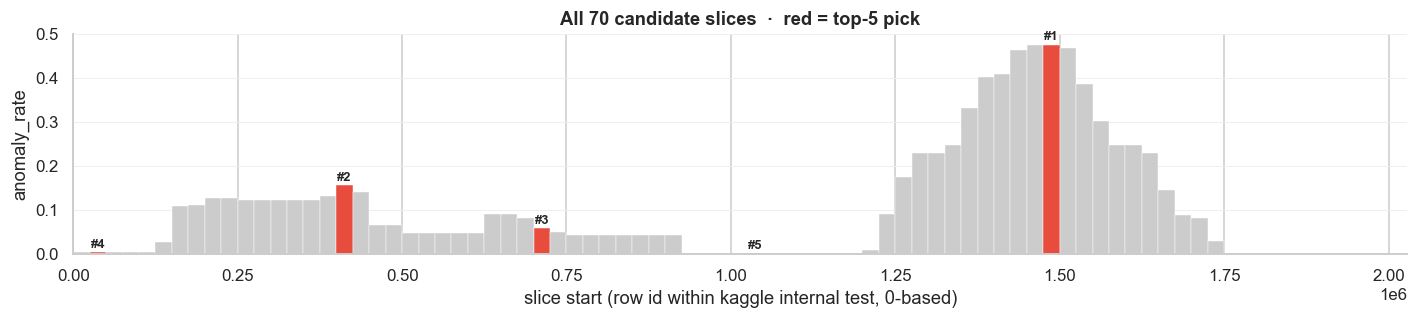

In [7]:
# All candidate slices as bars (grey), top-K picks highlighted (red) with rank labels.
picked_starts = set(int(s) for s in picked_df['start'])
colors = [ANOMALY_COLOR if int(s) in picked_starts else '#cccccc' for s in cand_df['start']]

fig, ax = plt.subplots(figsize=(13, 3.0))
ax.bar(cand_df['start'], cand_df['anomaly_rate'],
       width=STRIDE, color=colors, edgecolor='white', linewidth=0.3, align='edge')

for _, p in picked_df.iterrows():
    ax.annotate(f"#{int(p['rank'])}",
                (p['start'] + STRIDE / 2, p['anomaly_rate']),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8.5, fontweight='bold')

ax.set_xlim(0, len(X_int))
ax.set_xlabel('slice start (row id within kaggle internal test, 0-based)')
ax.set_ylabel('anomaly_rate')
ax.set_title(f'All {len(cand_df)} candidate slices  ·  red = top-{len(picked_df)} pick',
             fontweight='bold')
ax.grid(True, axis='y', color='#eeeeee', lw=0.6, zorder=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.show()

## 7 - Timeline plots for the top slices

Each slice is plotted with `plot_timeline` (the same renderer the API showcase
uses) so we can eyeball whether the events are visually distinct and whether
the FE model's predictions land where they should. `log_y=True` because the
score range spans multiple decades.

Note: scores shown are **post-detrend** (the FE pipeline output), so the
threshold line is `sidecar['threshold']` (the tuned value), not `PCA_THRESHOLD`.

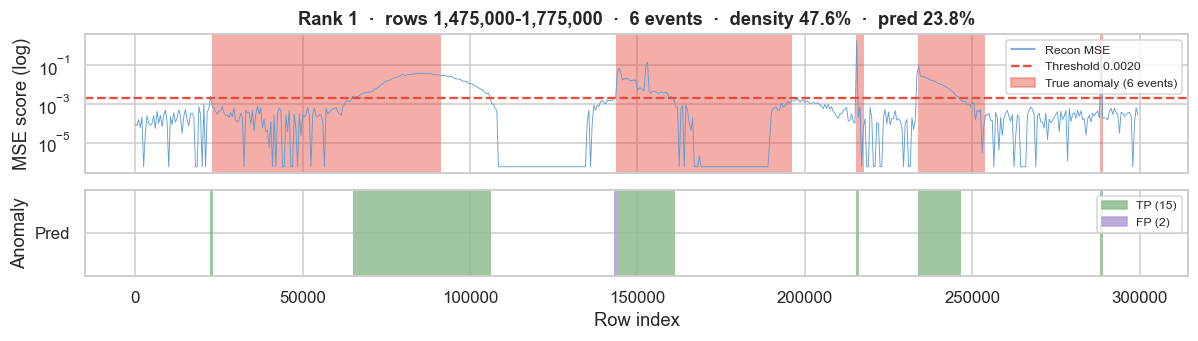

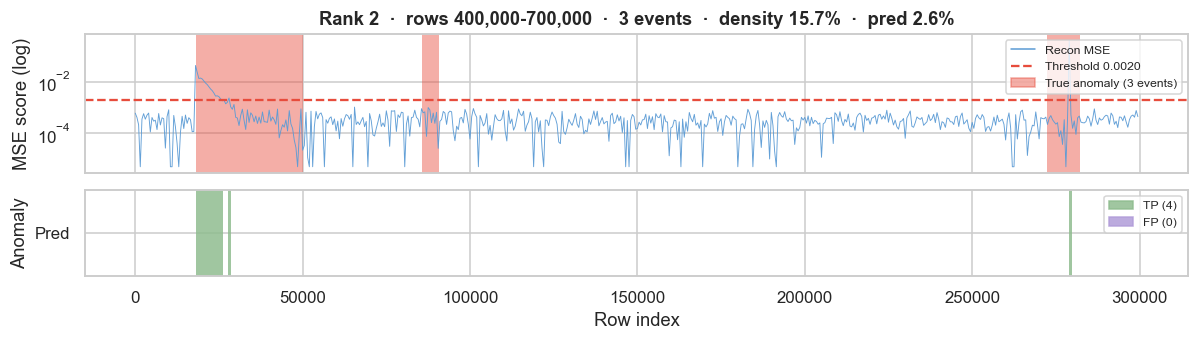

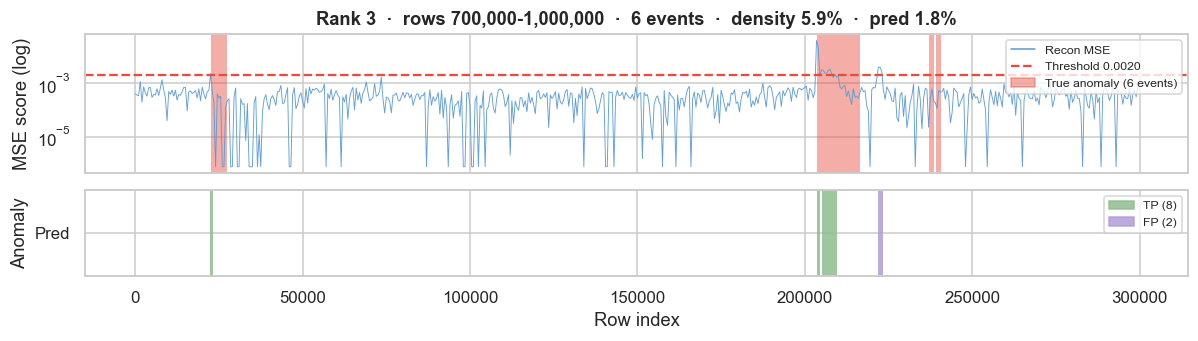

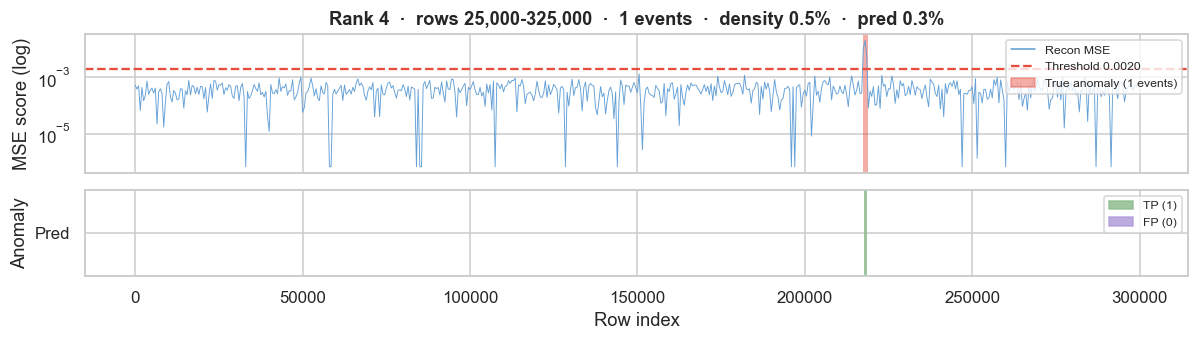

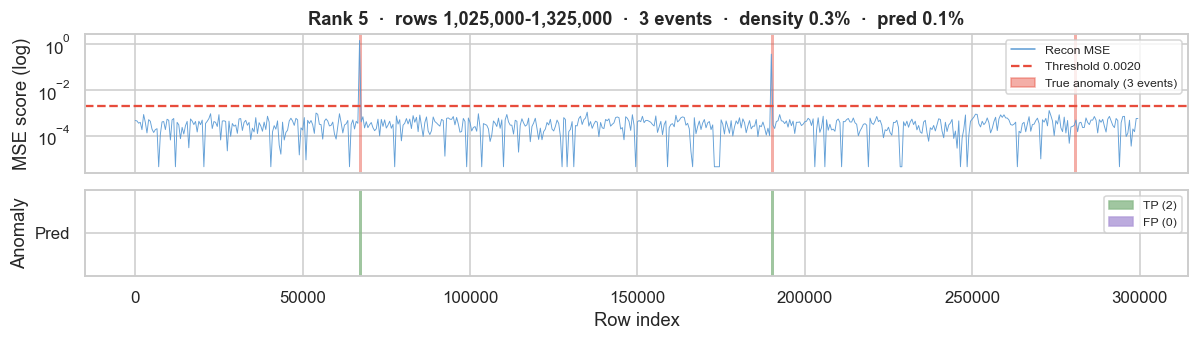

In [8]:
for _, row in picked_df.iterrows():
    s, e = int(row['start']), int(row['end'])
    fig = plot_timeline(
        scores=scores[s:e],
        y_true=y_int[s:e],
        threshold=threshold,
        title=(f"Rank {int(row['rank'])}  ·  rows {s:,}-{e:,}  ·  "
               f"{int(row['n_events'])} events  ·  density {row['anomaly_rate']:.1%}  "
               f"·  pred {row['pred_rate']:.1%}"),
        log_y=True,
        figsize=(11, 3.2),
    )
    plt.show()

## 8 - Manual slice explorer

The ranked candidates use a fixed `SLICE_LEN` and `STRIDE` grid - good for
narrowing down a region but it can miss the exact start/end you'd like for the
demo. Drop arbitrary row IDs into `MANUAL_SLICES` to render any range you want
(no window alignment required for *viewing*; only enforce it before saving).

In [ ]:
MANUAL_SLICES = [
    (0, 300_000),
    (700_000, 1_000_000),
    (1_475_000, 1_775_000),    # FE demo slice (6 events, ~47.6% density)
]

manual_rows = []
for s, e in MANUAL_SLICES:
    s, e = int(s), int(e)
    assert 0 <= s < e <= len(X_int), f'slice {s}-{e} out of bounds (max {len(X_int):,})'
    inside = (ev_starts >= s) & (ev_ends < e)
    manual_rows.append({
        'start'        : s,
        'end'          : e,
        'length'       : e - s,
        'n_events'     : int(inside.sum()),
        'anomaly_rate' : float(y_int[s:e].mean()),
        'pred_rate'    : float(y_pred_clean[s:e].mean()),
        'win_aligned'  : (s % WINDOW_SIZE == 0) and (e % WINDOW_SIZE == 0),
    })
manual_df = pd.DataFrame(manual_rows)
print('Manual slices:')
print(manual_df.to_string(index=False))

for _, row in manual_df.iterrows():
    s, e = int(row['start']), int(row['end'])
    align_note = '' if row['win_aligned'] else '  (NOT window-aligned - fine for viewing, re-align before saving)'
    fig = plot_timeline(
        scores=scores[s:e],
        y_true=y_int[s:e],
        threshold=threshold,
        title=(f"Manual  ·  rows {s:,}-{e:,}  ·  len {e-s:,}  ·  "
               f"{int(row['n_events'])} events  ·  density {row['anomaly_rate']:.1%}  "
               f"·  pred {row['pred_rate']:.1%}{align_note}"),
        log_y=True,
        figsize=(11, 3.2),
    )
    plt.show()

## 9 - Save a slice as `test_api*` for the FastAPI demo

Saves the **raw 58-channel** rows (not the 46ch detrended ones) so the
`predict_fe46` API path runs the full recipe end-to-end on the demo. Both
`SAVE_START` and `SAVE_END` must be multiples of `WINDOW_SIZE`.

Uncomment the `np.save` lines once you've picked a slice you like.

In [ ]:
SAVE_START = 1_475_000
SAVE_END   = 1_775_000

assert SAVE_START % WINDOW_SIZE == 0 and SAVE_END % WINDOW_SIZE == 0, \
    f'slice must be window-aligned (multiple of {WINDOW_SIZE}); got {SAVE_START}, {SAVE_END}'
assert 0 <= SAVE_START < SAVE_END <= len(X_int), \
    f'slice {SAVE_START}-{SAVE_END} out of bounds (max {len(X_int):,})'

inside = (ev_starts >= SAVE_START) & (ev_ends < SAVE_END)
print(f'Slice rows {SAVE_START:,}-{SAVE_END:,}  (length {SAVE_END-SAVE_START:,})')
print(f'  events       : {int(inside.sum())}')
print(f'  anomaly rate : {y_int[SAVE_START:SAVE_END].mean():.2%}')
print(f'  predicted    : {y_pred_clean[SAVE_START:SAVE_END].mean():.2%}')

# Read the raw 58ch rows so the API runs predict_fe46 end-to-end (scaler + slice + detrend).
abs_start = VAL_END + SAVE_START
abs_end   = VAL_END + SAVE_END
print(f'\nAbsolute rows in train.parquet: {abs_start:,}..{abs_end:,}')

In [ ]:
# Uncomment to save.
# df_train = pd.read_parquet(PROJECT_ROOT / 'data' / 'raw' / 'train.parquet')
# X_save = df_train.iloc[abs_start:abs_end][target_channels_full].values.astype(np.float32)
# np.save(PROCESSED_DIR / f'test_api_fe.npy',   X_save)
# np.save(PROCESSED_DIR / f'y_test_api_fe.npy', y_int[SAVE_START:SAVE_END])
# print(f'\nSaved: test_api_fe.npy  +  y_test_api_fe.npy')


Saved: test_api_fe.npy  +  y_test_api_fe.npy
